1. Imports and Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from sklearn.calibration import calibration_curve

2. Dataset Generation

In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(seed=55)
n = 1200

employment_type = rng.choice(["Salaried", "Self-Employed", "Contract"], size=n, p=[0.5, 0.28, 0.22])
credit_score = rng.normal(650, 60, size=n).clip(300, 850).round(0)
applicant_income = rng.normal(55000, 20000, size=n).clip(15000, None).round(0)
loan_amount = rng.normal(15000, 7000, size=n).clip(1000, None).round(0)

loan_to_income = loan_amount / applicant_income
emp_risk = pd.Series(employment_type).map({"Salaried": 0, "Self-Employed": 0.3, "Contract": 0.6}).values
z = (-0.035 * (credit_score - 650) + 4.5 * loan_to_income + emp_risk * 1.2 - 1.0 + rng.normal(0, 1.1, size=n))
prob_default = 1 / (1 + np.exp(-z))
default = (rng.uniform(size=n) < prob_default).astype(int)

missing_idx = rng.choice(n, 90, replace=False)
credit_score[missing_idx] = np.nan

loans = pd.DataFrame({
    "applicant_id": np.arange(1, n + 1),
    "employment_type": employment_type,
    "credit_score": credit_score,
    "applicant_income": applicant_income,
    "loan_amount": loan_amount,
    "default": default,
})


3. Dataset Setup Verification

In [3]:
assert loans.shape == (1200, 6)
assert loans["credit_score"].isna().sum() == 90
print("Setup confirmed — dataset matches spec.")


Setup confirmed — dataset matches spec.


In [4]:
loans.head()

,applicant_id,employment_type,credit_score,applicant_income,loan_amount,default
0,1,Contract,731.0,78406.0,8301.0,0
1,2,Contract,717.0,59130.0,6699.0,0
2,3,Salaried,713.0,71809.0,4456.0,1
3,4,Salaried,625.0,41497.0,20290.0,1
4,5,Salaried,652.0,64193.0,10890.0,0


4. Build Features

In [5]:
X = loans[[
        "credit_score",
        "applicant_income",
        "loan_amount",
        "employment_type"
    ]]

X = pd.get_dummies(
    X,
    columns=["employment_type"],
    drop_first=True
)

y = loans["default"]

5. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

6. Train-Only Imputation

In [7]:
credit_score_imputation_value = X_train["credit_score"].median()

X_train["credit_score"] = X_train["credit_score"].fillna(
    credit_score_imputation_value
)

X_test["credit_score"] = X_test["credit_score"].fillna(
    credit_score_imputation_value
)

print(
    f"Training-set median used for imputation: "
    f"{credit_score_imputation_value:.4f}"
)

print("\nMissing values after imputation:")
print(f"X_train credit_score: {X_train['credit_score'].isna().sum()}")
print(f"X_test credit_score: {X_test['credit_score'].isna().sum()}")

Training-set median used for imputation: 649.0000

Missing values after imputation:
X_train credit_score: 0
X_test credit_score: 0


### Interpretation

The missing `credit_score` values were imputed using the **training-set median of 649.0000**.

The same imputation value was applied to both the training and test sets. After imputation, there are **0 missing values** in `credit_score` for both `X_train` and `X_test`.

This approach avoids data leakage because the imputation value was calculated using **only the training data**, without using information from the test set.


### 7. Baseline Model

Firstly i establish a simple baseline using `DummyClassifier` with the `most_frequent` strategy.

This model always predicts the most common class in the training data, without learning relationships between the features and the target.

The baseline provides a reference point for evaluating whether the machine learning models provide meaningful improvement.


In [8]:
baseline_model = DummyClassifier(strategy="most_frequent")

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.6000


### Interpretation

The baseline model achieved an accuracy of **0.6000 (60%)**.

Because the `most_frequent` strategy always predicts the majority class, this score represents the performance we would obtain without learning any relationship between the input features and loan default.

This **60% baseline** will be used as the reference point for comparing Logistic Regression, Decision Tree, and Random Forest. A useful machine learning model should provide better performance than this baseline while also considering other metrics such as precision, recall, F1-score, and ROC-AUC.


### 7.1 Baseline Evaluation Metrics

Now i evaluate the baseline using accuracy, precision, recall, F1-score, and ROC-AUC.

These metrics provide a more complete view of model performance than accuracy alone. In particular, precision and recall help evaluate how well the model identifies the default class, while ROC-AUC measures the model's ability to distinguish between the two classes.


In [9]:
baseline_precision = precision_score(y_test, y_pred_baseline, zero_division=0)
baseline_recall = recall_score(y_test, y_pred_baseline, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, zero_division=0)

baseline_prob = baseline_model.predict_proba(X_test)[:, 1]
baseline_roc_auc = roc_auc_score(y_test, baseline_prob)

print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1-score:  {baseline_f1:.4f}")
print(f"ROC-AUC:   {baseline_roc_auc:.4f}")

Accuracy:  0.6000
Precision: 0.6000
Recall:    1.0000
F1-score:  0.7500
ROC-AUC:   0.5000


### Interpretation

The baseline achieved an accuracy of **0.6000**, meaning it correctly classified 60% of the test cases by always predicting the most frequent class.

Its precision is **0.6000**, which means that 60% of the cases predicted as default were actually defaults.

The recall is **1.0000**, because the baseline predicts the majority class for every applicant and therefore identifies all actual default cases. However, this does not mean that the baseline is a useful model, because it does not learn any relationship between the input features and the target.

The F1-score is **0.7500**, resulting from the combination of precision and recall.

The ROC-AUC is **0.5000**, which indicates that the baseline has no ability to distinguish between default and non-default cases beyond random ranking.

Overall, the baseline provides a reference point. The actual machine learning models should be evaluated against these results to determine whether they learn useful patterns from the applicant features.


### 8. Logistic Regression

Now i train a Logistic Regression model using the same training and test split used for the baseline.

The model learns the relationship between the applicant features and the probability of loan default. It is trained only on `X_train` and `y_train`, while `X_test` is used only for evaluation.


### 8A. Logistic Regression Without Standardization

First, i train Logistic Regression using the imputed features without applying feature scaling.

This version is used as a reference so that we can compare its performance with Logistic Regression trained on standardized features.


In [10]:
logistic_model_unscaled = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model_unscaled.fit(X_train, y_train)

y_pred_logistic_unscaled = logistic_model_unscaled.predict(X_test)
y_prob_logistic_unscaled = logistic_model_unscaled.predict_proba(X_test)[:, 1]

print("Logistic Regression without standardization completed.")

Logistic Regression without standardization completed.


### 8B. Logistic Regression With Standardization

Next, i train Logistic Regression after standardizing the features.

`StandardScaler` transforms the features so that they are on a comparable scale. The scaler is fitted only on the training data and then applied to the test data.

This version allows us to observe whether standardization affects Logistic Regression performance.


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model_scaled = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model_scaled.fit(X_train_scaled, y_train)

y_pred_logistic_scaled = logistic_model_scaled.predict(X_test_scaled)
y_prob_logistic_scaled = logistic_model_scaled.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression with standardization completed.")

Logistic Regression with standardization completed.


### 8C. Comparing Logistic Regression With and Without Standardization

Now i compare the performance of Logistic Regression before and after standardization using the same test set.

The comparison includes accuracy, precision, recall, F1-score, and ROC-AUC. This helps us determine whether standardization affected the model's predictive performance.


In [12]:
logistic_unscaled_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_logistic_unscaled),
    "precision": precision_score(
        y_test, y_pred_logistic_unscaled, zero_division=0
    ),
    "recall": recall_score(
        y_test, y_pred_logistic_unscaled, zero_division=0
    ),
    "f1": f1_score(
        y_test, y_pred_logistic_unscaled, zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test, y_prob_logistic_unscaled
    )
}

logistic_scaled_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_logistic_scaled),
    "precision": precision_score(
        y_test, y_pred_logistic_scaled, zero_division=0
    ),
    "recall": recall_score(
        y_test, y_pred_logistic_scaled, zero_division=0
    ),
    "f1": f1_score(
        y_test, y_pred_logistic_scaled, zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test, y_prob_logistic_scaled
    )
}

comparison = pd.DataFrame(
    {
        "Without Standardization": logistic_unscaled_metrics,
        "With Standardization": logistic_scaled_metrics
    }
)

print(comparison.round(4))

           Without Standardization  With Standardization
accuracy                    0.7500                0.7458
precision                   0.7692                0.7677
recall                      0.8333                0.8264
f1                          0.8000                0.7960
roc_auc                     0.8453                0.8454


### 9. Decision Tree

Next, i train a Decision Tree classifier using the same training and testing split. The model will use the imputed features and will be evaluated on the unseen test set.


### Decision Tree Depth Tuning

A Decision Tree can become too simple or too complex depending on its maximum depth. We will compare several depth values using the same training and test sets and select a suitable depth based on test performance.


In [13]:
depth_results = []

for depth in [2, 3, 4, 5, 6, 8, 10, None]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    depth_results.append({
        "max_depth": depth if depth is not None else "None",
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test, y_prob
        )
    })

depth_comparison = pd.DataFrame(depth_results)

print(depth_comparison.round(4))

  max_depth  accuracy  precision  recall      f1  roc_auc
0         2    0.7167     0.7754  0.7431  0.7589   0.7975
1         3    0.7208     0.7770  0.7500  0.7633   0.8149
2         4    0.7375     0.7682  0.8056  0.7864   0.8267
3         5    0.7292     0.7762  0.7708  0.7735   0.8211
4         6    0.7500     0.7917  0.7917  0.7917   0.8205
5         8    0.7000     0.7432  0.7639  0.7534   0.7489
6        10    0.7042     0.7483  0.7639  0.7560   0.7236
7      None    0.6917     0.7333  0.7639  0.7483   0.6736


### Interpretation

The Decision Tree performance improved as the maximum depth increased up to 6. The model achieved its highest accuracy and F1-score at **max_depth = 6**, with accuracy of **0.7500** and F1-score of **0.7917**. Performance decreased at deeper values, including 8, 10, and unrestricted depth, suggesting that excessive tree depth may lead to overfitting. Therefore, **max_depth = 6** is selected for the final Decision Tree model.


### Final Decision Tree

Based on the depth comparison, `max_depth = 6` is selected for the final Decision Tree because it achieved the strongest overall test performance among the evaluated depths.


In [14]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

decision_tree_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_tree),
    "precision": precision_score(
        y_test, y_pred_tree, zero_division=0
    ),
    "recall": recall_score(
        y_test, y_pred_tree, zero_division=0
    ),
    "f1": f1_score(
        y_test, y_pred_tree, zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test, y_prob_tree
    )
}

for metric, value in decision_tree_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

Accuracy: 0.7500
Precision: 0.7917
Recall: 0.7917
F1: 0.7917
Roc_auc: 0.8205


### Interpretation

The final Decision Tree with `max_depth = 6` achieved an accuracy of **0.7500**, precision of **0.7917**, recall of **0.7917**, F1-score of **0.7917**, and ROC-AUC of **0.8205** on the test set. The selected depth provided better performance than the other tested depth values, while deeper trees showed a decline in performance.


### 10. Random Forest Tree Count Tuning

Random Forest combines multiple decision trees. The number of trees (`n_estimators`) can affect model performance and stability. We will compare different numbers of trees using the same training and test sets and select a suitable value based on test performance.


In [15]:
tree_count_results = []

for n_trees in [50, 100, 150, 200, 300]:
    model = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tree_count_results.append({
        "n_estimators": n_trees,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test, y_prob
        )
    })

tree_count_comparison = pd.DataFrame(tree_count_results)

print(tree_count_comparison.round(4))

   n_estimators  accuracy  precision  recall      f1  roc_auc
0            50    0.7458     0.7643  0.8333  0.7973   0.8150
1           100    0.7708     0.7908  0.8403  0.8148   0.8198
2           150    0.7583     0.7792  0.8333  0.8054   0.8180
3           200    0.7708     0.7947  0.8333  0.8136   0.8230
4           300    0.7625     0.7881  0.8264  0.8068   0.8261


### Interpretation

The Random Forest achieved its strongest overall classification performance with `n_estimators = 100`. It achieved an accuracy of **0.7708**, recall of **0.8403**, and F1-score of **0.8148**. Although larger forests achieved slightly higher ROC-AUC, they did not improve the overall classification performance. Therefore, **100 trees** is selected for the final Random Forest model.


## Final Random Forest Model

Based on the tree-count comparison, `n_estimators = 100` is selected for the final Random Forest because it achieved the strongest overall classification performance among the tested values.

In [16]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

random_forest_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(
        y_test, y_pred_rf, zero_division=0
    ),
    "recall": recall_score(
        y_test, y_pred_rf, zero_division=0
    ),
    "f1": f1_score(
        y_test, y_pred_rf, zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test, y_prob_rf
    )
}

for metric, value in random_forest_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

Accuracy: 0.7708
Precision: 0.7908
Recall: 0.8403
F1: 0.8148
Roc_auc: 0.8198


### Interpretation

The final Random Forest model with `n_estimators = 100` achieved an accuracy of 0.7708, precision of 0.7908, recall of 0.8403, F1-score of 0.8148, and ROC-AUC of 0.8198 on the test set.

The model identifies a high proportion of actual default cases, as shown by its recall, while maintaining a good balance between precision and recall. Its F1-score is also strong, indicating balanced classification performance.

Among the tested Random Forest configurations, 100 trees provided the strongest overall classification performance, so this configuration is retained as the final Random Forest model.

## Model Comparison

The final versions of all models are compared using accuracy, precision, recall, F1-score, and ROC-AUC on the same test set. This provides a consistent basis for evaluating their classification performance.

In [17]:
model_metrics = {
    "Baseline": {
        "accuracy": baseline_accuracy,
        "precision": baseline_precision,
        "recall": baseline_recall,
        "f1": baseline_f1,
        "roc_auc": baseline_roc_auc
    },
    "Logistic Regression": {
        "accuracy": logistic_unscaled_metrics["accuracy"],
        "precision": logistic_unscaled_metrics["precision"],
        "recall": logistic_unscaled_metrics["recall"],
        "f1": logistic_unscaled_metrics["f1"],
        "roc_auc": logistic_unscaled_metrics["roc_auc"]
    },
    "Decision Tree": decision_tree_metrics,
    "Random Forest": random_forest_metrics
}

model_comparison = pd.DataFrame(model_metrics).T

print(model_comparison.round(4))

                     accuracy  precision  recall      f1  roc_auc
Baseline               0.6000     0.6000  1.0000  0.7500   0.5000
Logistic Regression    0.7500     0.7692  0.8333  0.8000   0.8453
Decision Tree          0.7500     0.7917  0.7917  0.7917   0.8205
Random Forest          0.7708     0.7908  0.8403  0.8148   0.8198


### Interpretation

The Random Forest achieved the highest accuracy of 0.7708 and the highest F1-score of 0.8148 among the final models. It also achieved a strong recall of 0.8403, meaning it identified a high proportion of actual default cases.

Logistic Regression achieved the highest ROC-AUC of 0.8453, indicating the strongest overall ranking/discrimination based on predicted probabilities. However, its accuracy and F1-score were lower than those of the Random Forest.

The Decision Tree achieved similar accuracy to Logistic Regression but had lower recall and F1-score.

The baseline achieved an accuracy of 0.6000 and ROC-AUC of 0.5000, so the trained models provided substantially better predictive performance.

Considering the overall balance of accuracy, recall, and F1-score, the Random Forest is selected as the final model.

## Final Model Selection

In [18]:
final_model = random_forest_model
final_model_name = "random_forest"

print(f"Final model: {final_model_name}")

Final model: random_forest


## Model Comparison

The final models are compared using accuracy, precision, recall, F1-score, and ROC-AUC. This visualization provides an overall view of the relative performance of the baseline and trained models.

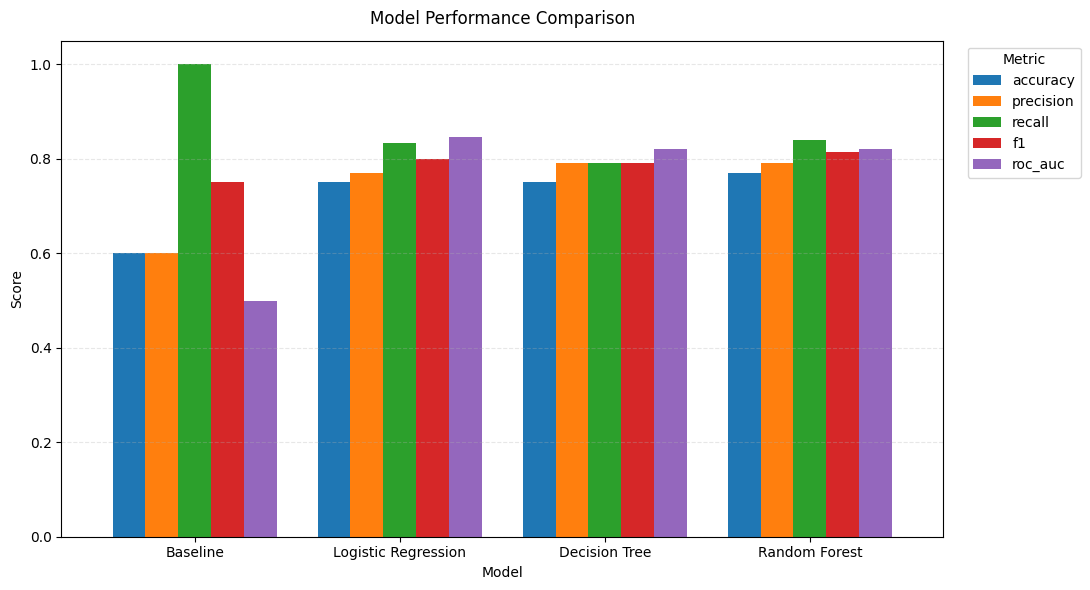

In [19]:
ax = model_comparison.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.8
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison", pad=12)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

ax.set_ylim(0, 1.05)

ax.legend(
    title="Metric",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True
)

ax.grid(
    axis="y",
    alpha=0.3,
    linestyle="--"
)

plt.tight_layout()

plt.savefig(
    "chart_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The model comparison shows that all three trained models outperform the baseline across the main evaluation metrics. Logistic Regression and Decision Tree provide similar performance, while Random Forest achieves the strongest overall and most balanced results. Random Forest has the highest accuracy, recall, and F1-score among the trained models, while also maintaining a high ROC-AUC. This indicates that Random Forest provides a better balance between correctly identifying default cases and maintaining overall classification performance. Therefore, Random Forest is selected as the final model for further error analysis and calibration.


## 11. Error Analysis

The final Random Forest predictions are compared with the true test labels to identify misclassified cases. We will inspect these errors to determine whether they show any noticeable pattern in credit score, applicant income, loan amount, or employment type.

In [20]:
error_analysis = X_test.copy()

error_analysis["actual"] = y_test
error_analysis["predicted"] = y_pred_rf
error_analysis["correct"] = (
    error_analysis["actual"] == error_analysis["predicted"]
)

misclassified = error_analysis[
    ~error_analysis["correct"]
].copy()

print(f"Total test samples: {len(error_analysis)}")
print(f"Misclassified samples: {len(misclassified)}")
print(
    f"Misclassification rate: "
    f"{len(misclassified) / len(error_analysis):.4f}"
)

print("\nMisclassified cases:")
display(misclassified.head(10))

Total test samples: 240
Misclassified samples: 55
Misclassification rate: 0.2292

Misclassified cases:


,credit_score,applicant_income,loan_amount,employment_type_Salaried,employment_type_Self-Employed,actual,predicted,correct
88,650.0,48511.0,18965.0,False,False,0,1,False
663,629.0,55250.0,11096.0,False,False,0,1,False
124,647.0,48595.0,23336.0,True,False,0,1,False
1018,710.0,70560.0,16091.0,False,False,1,0,False
844,660.0,95036.0,10441.0,True,False,1,0,False
737,649.0,20544.0,17601.0,False,True,0,1,False
425,707.0,48108.0,20962.0,True,False,1,0,False
218,658.0,83527.0,23569.0,False,False,0,1,False
924,674.0,44522.0,25251.0,True,False,0,1,False
628,669.0,57550.0,19184.0,True,False,0,1,False


### False Positives and False Negatives

We separate the misclassified test cases into false positives and false negatives to understand the type of errors made by the final Random Forest model.

- **False Positive:** The model predicted default, but the actual class was non-default.
- **False Negative:** The model predicted non-default, but the actual class was default.

In [21]:
false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
].copy()

false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
].copy()

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

print(
    f"\nFalse-positive rate among errors: "
    f"{len(false_positives) / len(misclassified):.4f}"
)

print(
    f"False-negative rate among errors: "
    f"{len(false_negatives) / len(misclassified):.4f}"
)

False positives: 32
False negatives: 23

False-positive rate among errors: 0.5818
False-negative rate among errors: 0.4182


### Error Pattern Analysis

Now i compare the feature characteristics of misclassified cases with the overall test set to identify whether certain applicant profiles are more difficult for the model to classify correctly.

In [22]:
numeric_features = [
    "credit_score",
    "applicant_income",
    "loan_amount"
]

print("Average values in the full test set:")
print(X_test[numeric_features].mean().round(2))

print("\nAverage values among misclassified cases:")
print(misclassified[numeric_features].mean().round(2))

print("\nAverage values for false positives:")
print(false_positives[numeric_features].mean().round(2))

print("\nAverage values for false negatives:")
print(false_negatives[numeric_features].mean().round(2))

Average values in the full test set:
credit_score          648.68
applicant_income    55896.12
loan_amount         15710.70
dtype: float64

Average values among misclassified cases:
credit_score          667.58
applicant_income    55266.84
loan_amount         16439.02
dtype: float64

Average values for false positives:
credit_score          652.41
applicant_income    55454.84
loan_amount         18267.72
dtype: float64

Average values for false negatives:
credit_score          688.70
applicant_income    55005.26
loan_amount         13894.74
dtype: float64


### Interpretation

The error analysis shows that the misclassified cases have a slightly higher average credit score than the overall test set. False negatives have the highest average credit score, while false positives have a higher average loan amount.

This suggests that some default cases have relatively strong credit scores, making them harder for the model to identify as defaults. On the other hand, some non-default applicants have relatively high loan amounts, which may cause the model to incorrectly predict default.

Overall, the errors do not appear to be caused by a single feature alone. They indicate that some applicant profiles have overlapping characteristics between the default and non-default classes, making them difficult to classify correctly.

## Calibration Analysis

Calibration evaluates whether the probabilities predicted by the final Random Forest model are reasonably aligned with the observed frequency of defaults.

A well-calibrated model should produce probabilities that correspond approximately to the actual proportion of positive cases.

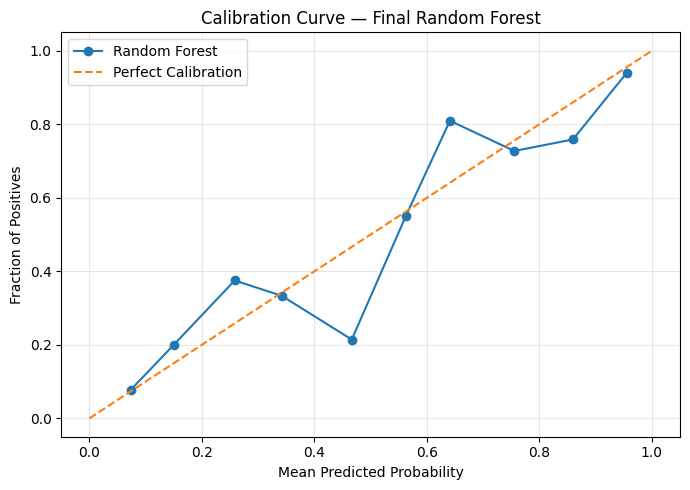

In [23]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_rf,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Final Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("chart_calibration.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The calibration curve shows that the Random Forest probabilities are reasonably aligned with the observed fraction of positive cases, although the curve does not follow the perfect-calibration line exactly.

Some probability bins lie above the reference line, while others lie below it. This indicates that the predicted probabilities are not perfectly calibrated and may sometimes overestimate or underestimate the actual default frequency.

Overall, the model provides useful probability estimates, but the predicted probabilities should not automatically be treated as exact real-world default probabilities without further calibration and validation.

### Save Model Evaluation Metrics

The evaluation metrics for all four models are saved in a JSON file for reproducibility and reporting. The metrics are taken directly from the calculated model comparison results rather than being manually entered. The training-set median used for `credit_score` imputation is also stored, along with the selected final model.

This ensures that the saved evaluation results remain consistent with the actual model performance obtained during the pipeline.


In [24]:
import json

model_metrics = {
    "baseline": {
        k: float(v)
        for k, v in model_comparison.loc["Baseline"].items()
    },
    "logistic_regression": {
        k: float(v)
        for k, v in model_comparison.loc["Logistic Regression"].items()
    },
    "decision_tree": {
        k: float(v)
        for k, v in model_comparison.loc["Decision Tree"].items()
    },
    "random_forest": {
        k: float(v)
        for k, v in model_comparison.loc["Random Forest"].items()
    },
    "credit_score_imputation_value": float(credit_score_imputation_value),
    "final_model": "random_forest"
}

with open("model_metrics.json", "w") as f:
    json.dump(model_metrics, f, indent=4)

print("model_metrics.json created successfully.")

model_metrics.json created successfully.


In [25]:
full_dataset_median = loans["credit_score"].median()

print(
    f"Train-only imputation value: "
    f"{credit_score_imputation_value:.4f}"
)

print(
    f"Full-dataset median: "
    f"{full_dataset_median:.4f}"
)

Train-only imputation value: 649.0000
Full-dataset median: 650.0000
